In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path

import numpy as np
import seaborn as sns
import os

In [3]:
from analysis.utils import load_sweep_metadata, load_data
from analysis.utils_decoding import evaluate_lags_leave_k_out

In [4]:
def compute_success(df_data,
                    threshold_angle=0.1,
                    consecutive_steps=100,
                    starting_step=0,
                    column_name=None):
    """
    Compute whether the pole is upright (straight) for consecutive_steps time points.
    
    Args:
        df_data: DataFrame with 'observations' column containing state arrays
        threshold_angle: Maximum angle deviation from vertical (in radians) to consider "straight"
        consecutive_steps: Number of consecutive steps required for success
    
    Returns:
        df_data: DataFrame with added 'success' column and 'percentage_straight' column
    """
    success = []
    percentage_straight = []

    for idx in range(len(df_data)):
        observations = np.array(df_data['observations'].iloc[idx])
        observations = observations[starting_step:]

        # Extract cos and sin of pole angle (dimensions 1 and 2)
        cos_angle = observations[:, 1]
        sin_angle = observations[:, 2]

        # Compute actual angle from cos and sin
        angles = np.arctan2(sin_angle, cos_angle)

        # Check if angle is within threshold (close to 0, which is upright)
        is_straight = np.abs(angles) < threshold_angle

        # Compute percentage of steps with pole straight
        pct_straight = np.sum(is_straight) / len(is_straight) * 100
        percentage_straight.append(pct_straight)

        # Check for consecutive_steps consecutive True values
        episode_success = False
        count = 0
        for straight in is_straight:
            if straight:
                count += 1
                if count >= consecutive_steps:
                    episode_success = True
                    break
            else:
                count = 0

        success.append(episode_success)
    column_name = column_name if column_name is not None else 'success'
    df_data[column_name] = np.array(success)
    df_data['percentage_straight'] = np.array(percentage_straight)
    return df_data


def chunk_data(data, chunk_size=500):
    return [data[i:i + chunk_size] for i in range(0, len(data), chunk_size)]


## Load tdmpc2 data

In [5]:
df_metadata_tdmpc2 = load_sweep_metadata([
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep"
],
                                         json_file_name='episode_metadata.json')
df_metadata_tdmpc2 = df_metadata_tdmpc2[df_metadata_tdmpc2['model_step'] ==
                                        500_000]

df_metadata_tdmpc2 = df_metadata_tdmpc2[df_metadata_tdmpc2['seed'] == 1]

df_tdmpc2 = load_data(
    df_metadata_tdmpc2,
    episode_file_name='episode_data.pkl',
    #cart_position=0.,
)

df_tdmpc2.shape

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep:   0%|          | 0/108 [00:00<?, ?it/s]

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep: 100%|██████████| 108/108 [00:00<00:00, 405.82it/s]


Found 108 configurations
Found 18 configurations


100%|██████████| 18/18 [00:00<00:00, 327.78it/s]


(18, 17)

In [6]:
df_tdmpc2['initial_state_cart_position'] = df_tdmpc2['initial_state'].apply(
    lambda x: x[0])
df_tdmpc2['initial_state_pole_angle_rad'] = df_tdmpc2['initial_state'].apply(
    lambda x: x[1])
df_tdmpc2['initial_state_pole_angle_deg'] = np.degrees(
    df_tdmpc2['initial_state_pole_angle_rad'])


## Load sac data

In [7]:
df_metadata_sac = load_sweep_metadata([
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/pytorch_sac/logs/25-01-09-cartpole_initial_conditions_seeds_sweep"
],
                                      json_file_name='episode_0000_metadata.json'
                                     )

df_metadata_sac = df_metadata_sac[df_metadata_sac['seed'] == 1]

df_metadata_sac = df_metadata_sac[
    df_metadata_sac['initial_state_cart_position'].isin([-1, 0, 1])]

df_sac = load_data(
    df_metadata_sac,
    episode_file_name='episode_0000.pkl',
    #cart_position=0.,
)

df_sac['total_reward'] = df_sac['total_reward'] * 2

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/pytorch_sac/logs/25-01-09-cartpole_initial_conditions_seeds_sweep:   0%|          | 0/275 [00:00<?, ?it/s]

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/pytorch_sac/logs/25-01-09-cartpole_initial_conditions_seeds_sweep: 100%|██████████| 275/275 [00:00<00:00, 9028.13it/s]


Found 275 configurations
Found 33 configurations


100%|██████████| 33/33 [00:00<00:00, 234.36it/s]


In [19]:
## For the sake of comparison, only take the rows that have same angle

# Find common angles between SAC and TDMPC2
common_angles = set(df_sac['initial_state_pole_angle_deg'].unique()) & set(
    df_tdmpc2['initial_state_pole_angle_deg'].unique())
print(f"Common angles: {sorted(common_angles)}")

# Filter both dataframes to only include common angles
df_sac = df_sac[df_sac['initial_state_pole_angle_deg'].isin(common_angles)]
df_tdmpc2 = df_tdmpc2[df_tdmpc2['initial_state_pole_angle_deg'].isin(
    common_angles)]

print(f"SAC shape after filtering: {df_sac.shape}")
print(f"TDMPC2 shape after filtering: {df_tdmpc2.shape}")


Common angles: [0.0, 72.0, 144.0, 216.0, 288.0, 360.0]
SAC shape after filtering: (18, 24)
TDMPC2 shape after filtering: (18, 22)


In [20]:
df_sac = compute_success(df_sac, threshold_angle=0.1)
df_tdmpc2 = compute_success(df_tdmpc2, threshold_angle=0.1)

## Compare tdmpc2 and sac data in terms of success/reward

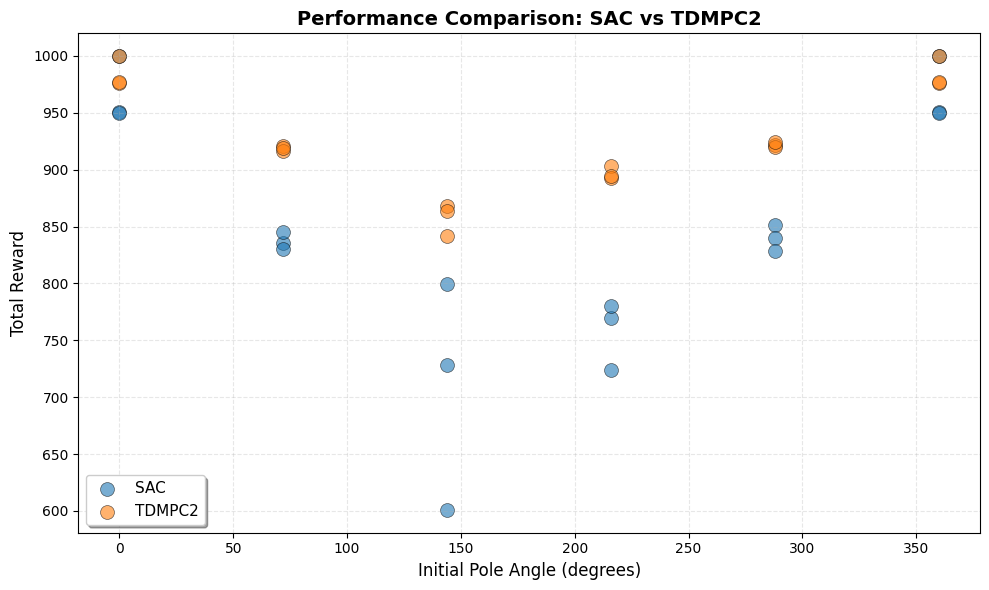

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot SAC data
ax.scatter(df_sac['initial_state_pole_angle_deg'],
           df_sac['total_reward'],
           label='SAC',
           alpha=0.6,
           s=100,
           edgecolors='black',
           linewidth=0.5)

# Plot TDMPC2 data
ax.scatter(df_tdmpc2['initial_state_pole_angle_deg'],
           df_tdmpc2['total_reward'],
           label='TDMPC2',
           alpha=0.6,
           s=100,
           edgecolors='black',
           linewidth=0.5)

ax.set_xlabel('Initial Pole Angle (degrees)', fontsize=12)
ax.set_ylabel('Total Reward', fontsize=12)
ax.set_title('Performance Comparison: SAC vs TDMPC2',
             fontsize=14,
             fontweight='bold')
ax.legend(fontsize=11, frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

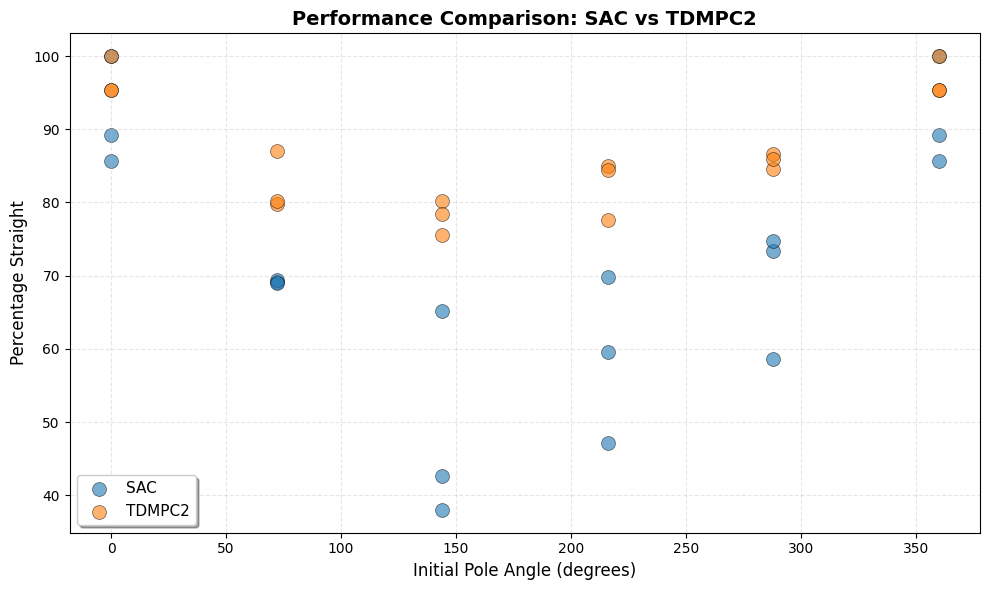

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot SAC data
ax.scatter(df_sac['initial_state_pole_angle_deg'],
           df_sac['percentage_straight'],
           label='SAC',
           alpha=0.6,
           s=100,
           edgecolors='black',
           linewidth=0.5)

# Plot TDMPC2 data
ax.scatter(df_tdmpc2['initial_state_pole_angle_deg'],
           df_tdmpc2['percentage_straight'],
           label='TDMPC2',
           alpha=0.6,
           s=100,
           edgecolors='black',
           linewidth=0.5)

ax.set_xlabel('Initial Pole Angle (degrees)', fontsize=12)
ax.set_ylabel('Percentage Straight', fontsize=12)
ax.set_title('Performance Comparison: SAC vs TDMPC2',
             fontsize=14,
             fontweight='bold')
ax.legend(fontsize=11, frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

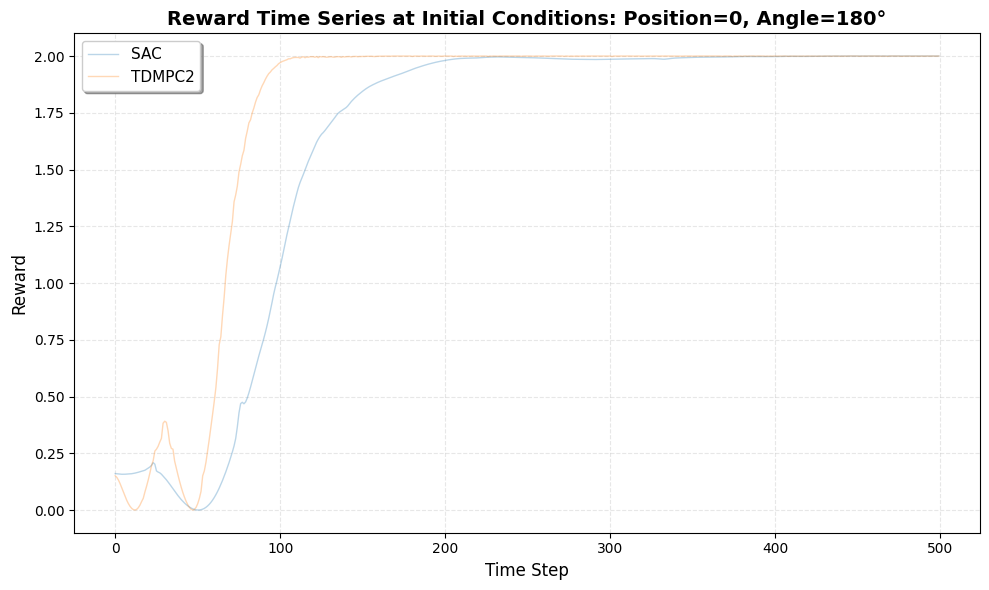

SAC episodes: 1, Mean total reward: 799.89
TDMPC2 episodes: 1, Mean total reward: 868.03


In [23]:
# Filter for initial conditions: cart position = 0, pole angle = 180 degrees
sac_180 = df_sac[(df_sac['initial_state_cart_position'] == 0) &
                 (df_sac['initial_state_pole_angle_deg'] == 144)]
tdmpc2_180 = df_tdmpc2[(df_tdmpc2['initial_state_cart_position'] == 0) &
                       (df_tdmpc2['initial_state_pole_angle_deg'] == 144)]

fig, ax = plt.subplots(figsize=(10, 6))

# Plot SAC rewards as time series
for idx, row in sac_180.iterrows():
    rewards = row['rewards'] * 2
    ax.plot(range(len(rewards)),
            rewards,
            label='SAC' if idx == sac_180.index[0] else '',
            alpha=0.3,
            linewidth=1)

# Plot TDMPC2 rewards as time series
for idx, row in tdmpc2_180.iterrows():
    rewards = row['rewards']
    ax.plot(range(len(rewards)),
            rewards,
            label='TDMPC2' if idx == tdmpc2_180.index[0] else '',
            alpha=0.3,
            linewidth=1)

ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Reward', fontsize=12)
ax.set_title('Reward Time Series at Initial Conditions: Position=0, Angle=180°',
             fontsize=14,
             fontweight='bold')
ax.legend(fontsize=11, frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(
    f"SAC episodes: {len(sac_180)}, Mean total reward: {sac_180['total_reward'].mean():.2f}"
)
print(
    f"TDMPC2 episodes: {len(tdmpc2_180)}, Mean total reward: {tdmpc2_180['total_reward'].mean():.2f}"
)


In [24]:
dim_names = {
    0: 'Cart Position',
    1: 'cos(Pole Angle)',
    2: 'sin(Pole Angle)',
    3: 'Cart Velocity',
    4: 'Pole Angular Velocity',
}

In [25]:
# df['init_cart_position'] = df['initial_state'].apply(lambda x: x[0])
# df['init_pole_angle'] = df['initial_state'].apply(lambda x: x[1])
# df['init_pole_angle_degrees'] = np.degrees(df['init_pole_angle'])
# df['init_pole_angle_str'] = df['init_pole_angle_degrees'].round(0).astype(str)

# for dim in range(5):
#     df[f'average_dim_{dim}'] = df['observations'].apply(
#         lambda x: np.mean(np.array(x)[:, dim]))

# df['total_position_change'] = df['observations'].apply(
#     lambda x: np.array(x)[-1, 0] - np.array(x)[0, 0])

# df['cumulative_abs_position_change'] = df['observations'].apply(
#     lambda x: np.sum(np.abs(np.diff(np.array(x)[:, 0]))))

# df['cumulative_position_change'] = df['observations'].apply(
#     lambda x: np.sum(np.diff(np.array(x)[:, 0])))

# df = df[~df['init_pole_angle_degrees'].isin([0, 360])]

## Decoding 

In [26]:
df_sac['actor_h1'] = df_sac['hidden_activations'].apply(lambda x: x['actor_h1'])
df_sac['actor_h2'] = df_sac['hidden_activations'].apply(lambda x: x['actor_h2'])
z_h2 = np.concatenate(df_sac['actor_h2'].tolist(), axis=0).squeeze()
z_h1 = np.concatenate(df_sac['actor_h1'].tolist(), axis=0).squeeze()
z_sac = np.hstack([z_h2, z_h1]).squeeze()
z_sac.shape

(9000, 2048)

In [27]:
vars_sac = {
    'z':
        z_h2,
    'obs':
        np.concatenate(df_sac['observations'].tolist()),
    'position':
        np.concatenate(df_sac['observations'].tolist())[:, 0].reshape(-1, 1),
    'cos(pole_angle)':
        np.concatenate(df_sac['observations'].tolist())[:, 1].reshape(-1, 1),
    'sin(pole_angle)':
        np.concatenate(df_sac['observations'].tolist())[:, 2].reshape(-1, 1),
    'cart_velocity':
        np.concatenate(df_sac['observations'].tolist())[:, 3].reshape(-1, 1),
    'pole_angular_velocity':
        np.concatenate(df_sac['observations'].tolist())[:, 4].reshape(-1, 1),
    'rewards':
        np.concatenate(df_sac['rewards'].tolist()).reshape(-1, 1),
    'actions':
        np.concatenate(df_sac['actions'].tolist()),
}

for key, value in vars_sac.items():
    print(f"{key}: {value.shape}")

vars_tdmpc2 = {
    'z':
        np.concatenate(df_tdmpc2['latent_states'].tolist()),
    'obs':
        np.concatenate(df_tdmpc2['observations'].tolist()),
    'position':
        np.concatenate(df_tdmpc2['observations'].tolist())[:, 0].reshape(-1, 1),
    'cos(pole_angle)':
        np.concatenate(df_tdmpc2['observations'].tolist())[:, 1].reshape(-1, 1),
    'sin(pole_angle)':
        np.concatenate(df_tdmpc2['observations'].tolist())[:, 2].reshape(-1, 1),
    'cart_velocity':
        np.concatenate(df_tdmpc2['observations'].tolist())[:, 3].reshape(-1, 1),
    'pole_angular_velocity':
        np.concatenate(df_tdmpc2['observations'].tolist())[:, 4].reshape(-1, 1),
    'rewards':
        np.concatenate(df_tdmpc2['rewards'].tolist()).reshape(-1, 1),
    'actions':
        np.concatenate(df_tdmpc2['actions'].tolist()),
}

for key, value in vars_tdmpc2.items():
    print(f"{key}: {value.shape}")

z: (9000, 1024)
obs: (9000, 5)
position: (9000, 1)
cos(pole_angle): (9000, 1)
sin(pole_angle): (9000, 1)
cart_velocity: (9000, 1)
pole_angular_velocity: (9000, 1)
rewards: (9000, 1)
actions: (9000, 1)
z: (9000, 512)
obs: (9000, 5)
position: (9000, 1)
cos(pole_angle): (9000, 1)
sin(pole_angle): (9000, 1)
cart_velocity: (9000, 1)
pole_angular_velocity: (9000, 1)
rewards: (9000, 1)
actions: (9000, 1)


In [28]:
all_combs = [
    ('z', 'obs'),
    ('z', 'position'),
    ('z', 'cos(pole_angle)'),
    ('z', 'sin(pole_angle)'),
    ('z', 'cart_velocity'),
    ('z', 'pole_angular_velocity'),
    ('z', 'rewards'),
    ('z', 'actions'),
    ('obs', 'obs'),
    ('position', 'position'),
    ('cos(pole_angle)', 'cos(pole_angle)'),
    ('sin(pole_angle)', 'sin(pole_angle)'),
    ('cart_velocity', 'cart_velocity'),
    ('pole_angular_velocity', 'pole_angular_velocity'),
    ('rewards', 'rewards'),
    ('actions', 'actions'),
]


In [ ]:
path_to_save = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_sac_vs_tdmpc2'
#path_to_save = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/pytorch_sac/analysis/'

for vars_key, vars in {'sac': vars_sac, 'tdmpc2': vars_tdmpc2}.items():
    for predict_type in ['difference', 'future']:
        results_decoding = {}
        for x_var, y_var in all_combs:
            print(f"Decoding {x_var} -> {y_var}")
            results_decoding[f'{x_var}-{y_var}'] = evaluate_lags_leave_k_out(
                chunk_data(vars[x_var], chunk_size=500),
                chunk_data(vars[y_var], chunk_size=500),
                model='lasso',
                lags=np.arange(-80, 81, 10),
                k_holdout=1,
                add_bootstrap_ci=True,
                shuffle_X=False,
                shuffle_y=False,
                predict_difference=True
                if predict_type == 'difference' else False)

        #Save results_decoding to pickle file
        with open(
                os.path.join(
                    path_to_save,
                    f'results_decoding_lasso_{predict_type}_{vars_key}.pkl'),
                'wb') as f:
            pickle.dump(results_decoding, f)

Decoding z -> obs
Number of episodes: 18
Number of combinations: 18


  0%|          | 0/18 [00:00<?, ?it/s]

/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.095e+01, tolerance: 2.601e+00
  model = cd_fast.enet_coordinate_descent(
/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.202e+01, tolerance: 2.567e+00
  model = cd_fast.enet_coordinate_descent(
/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations

Decoding z -> position
Number of episodes: 18
Number of combinations: 18


100%|██████████| 18/18 [01:25<00:00,  4.74s/it]


...

100%|██████████| 18/18 [00:00<00:00, 47.87it/s]


Decoding actions -> actions
Number of episodes: 18
Number of combinations: 18


100%|██████████| 18/18 [00:00<00:00, 48.69it/s]


Decoding z -> obs
Number of episodes: 18
Number of combinations: 18


  0%|          | 0/18 [00:00<?, ?it/s]/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.754e+00, tolerance: 1.692e+00
  model = cd_fast.enet_coordinate_descent(
 11%|█         | 2/18 [00:33<04:29, 16.83s/it]/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.298e+00, tolerance: 1.682e+00
  model = cd_fast.enet_coordinate_descent(
 22%|██▏       | 4/18 [01:05<03:49, 16.36s/it]/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_mod

In [58]:
path_to_save = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_workshop_121225'
with open(
        os.path.join(path_to_save,
                     'results_decoding_lasso_all_no0-360egrees.pkl'),
        'rb') as f:
    results_decoding_all = pickle.load(f)


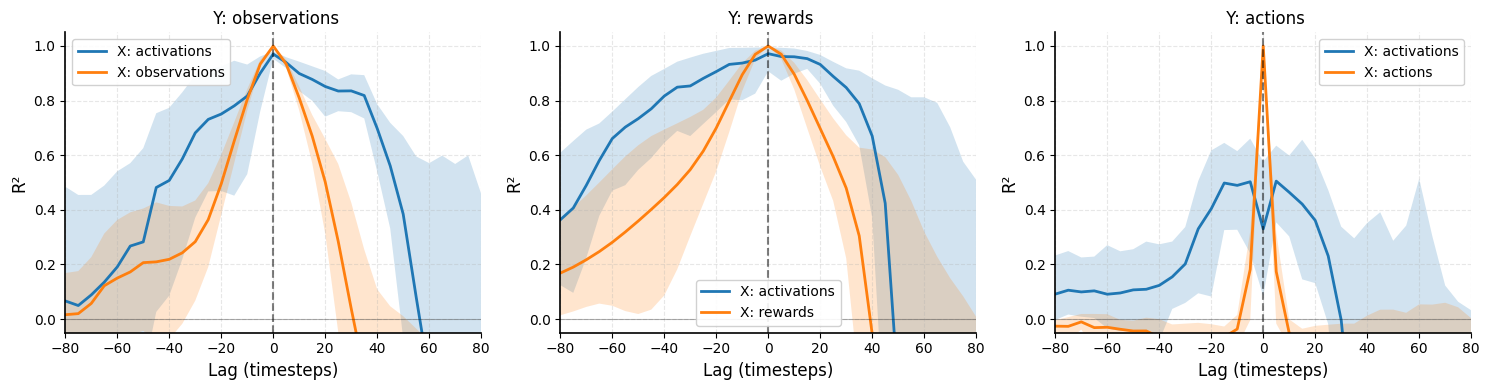

In [71]:
plot_dict = {
    0: ['z-obs', 'obs-obs'],
    1: ['z-rewards', 'rewards-rewards'],
    2: ['z-actions', 'actions-actions']
}

map_dict = {
    'z': 'activations',
    'obs': 'observations',
    'rewards': 'rewards',
    'actions': 'actions'
}

# Create a figure with as many subplots as keys in plot_dict
num_plots = len(plot_dict)
fig, axes = plt.subplots(1, num_plots, figsize=(15, 4))

# Handle case where there's only one subplot
if num_plots == 1:
    axes = [axes]

# Iterate through plot_dict
for plot_idx, key_list in plot_dict.items():
    ax = axes[plot_idx]

    # Plot each key in the list for this subplot
    for key in key_list:
        if key in results_decoding_all:
            results = results_decoding_all[key]

            r2_mean = results['r2_mean']
            r2_ci = results['r2_ci']

            # Extract lags and R² values from the dictionary
            lags = list(r2_mean.keys())
            means = list(r2_mean.values())

            # r2_ci is a tuple of (lower_dict, upper_dict)
            ci_lower = [r2_ci[lag][0] for lag in lags]
            ci_upper = [r2_ci[lag][1] for lag in lags]

            # Plot with label based on the key
            title = key.split('-')
            label = f'X: {map_dict[title[0]]}'
            ax.plot(lags, means, label=label, linewidth=2)
            ax.fill_between(lags, ci_lower, ci_upper, alpha=0.2)

    ax.set_xlabel('Lag (timesteps)', fontsize=12)
    ax.set_ylabel('R²', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-80, 80)
    ax.tick_params(labelsize=10)
    ax.set_title(f' Y: {map_dict[title[1]]}')
    # Add spines styling
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

#plt.suptitle('Decoding Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
sns.despine()
plt.show()

In [56]:
z_all.shape

(4500, 512)

In [53]:
mask_stabilization = obs_all[:, 1] >= 0.99
mask_swingup = ~mask_stabilization

z_stabilization = z_all[mask_stabilization]
z_swingup = z_all[mask_swingup]
rewards_stabilization = rewards_all[mask_stabilization]
rewards_swingup = rewards_all[mask_swingup]
obs_stabilization = obs_all[mask_stabilization]
obs_swingup = obs_all[mask_swingup]

In [55]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(z_swingup,
                                                    obs_swingup,
                                                    test_size=0.2,
                                                    random_state=42)

# Fit linear regression model
model_stabilization = LinearRegression()
model_stabilization.fit(X_train, y_train)

# Predict and calculate R²
y_pred_train = model_stabilization.predict(X_train)
y_pred_test = model_stabilization.predict(X_test)

r2_train = r2_score(y_train, y_pred_train, multioutput='variance_weighted')
r2_test = r2_score(y_test, y_pred_test, multioutput='variance_weighted')

print(f"Train R² score: {r2_train:.4f}")
print(f"Test R² score: {r2_test:.4f}")


Train R² score: 1.0000
Test R² score: 1.0000
